In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# GAS MDMS/HES DATA - IMPORT & CLEANING
# ============================================================

# ---------- 1. IMPORT ----------
file_path = "/content/Dataset_ALL_Combined.xlsx"

df = pd.read_excel(
    file_path,
    dtype={
        "Consumer ID": "string",
        "Meter ID": "string",
        "Reading Month": "string"
    }
)

df.columns = df.columns.astype(str).str.strip()

print("Original shape:", df.shape)



Original shape: (14720, 34)


In [ ]:
# ---------- 2. DAILY COLUMNS ----------
day_columns = [
    str(day)
    for day in range(1, 32)
    if str(day) in df.columns
]

for col in day_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


In [ ]:
print(df)

           Consumer ID          Meter ID Reading Month       1       2  \
0      017701704100320  AGZ2612000008569      Jul-2026   11.99   12.33   
1      100464006800000  ELS3032545179843      Jul-2026   23.05   23.36   
2      100461701500001  ELS3032545179844      Jul-2026   67.73   70.09   
3      100463400500352  ELS3032545179845      Jul-2026   39.52   42.41   
4      100459600500000  ELS3032545179846      Jul-2026   66.27   69.64   
...                ...               ...           ...     ...     ...   
14715  100465200005132  FIOR034426017721      Aug-2026   59.45   59.85   
14716  100461601300000  FIOR034426017722      Aug-2026  207.21  209.47   
14717  100465200000299  FIOR034426017723      Aug-2026   76.85   77.94   
14718  017701705100590  FIOR034426017724      Aug-2026  102.15  102.84   
14719  100474200101791  FIOR034426017725      Aug-2026    0.25    0.25   

            3       4       5       6       7  ...      22      23      24  \
0       12.87   13.23   14.00   1

In [ ]:

# ---------- 3. WIDE → LONG ----------
id_columns = [
    "Consumer ID",
    "Meter ID",
    "Reading Month"
]

long_df = df.melt(
    id_vars=id_columns,
    value_vars=day_columns,
    var_name="Day",
    value_name="Meter Reading"
)

long_df["Day"] = pd.to_numeric(
    long_df["Day"],
    errors="coerce"
).astype("Int64")

In [ ]:
# ---------- 4. CREATE DATE ----------
long_df["Date"] = pd.to_datetime(
    long_df["Reading Month"].astype(str)
    + "-"
    + long_df["Day"].astype(str),
    format="%b-%Y-%d",
    errors="coerce"
)
print(df)

           Consumer ID          Meter ID Reading Month       1       2  \
0      017701704100320  AGZ2612000008569      Jul-2026   11.99   12.33   
1      100464006800000  ELS3032545179843      Jul-2026   23.05   23.36   
2      100461701500001  ELS3032545179844      Jul-2026   67.73   70.09   
3      100463400500352  ELS3032545179845      Jul-2026   39.52   42.41   
4      100459600500000  ELS3032545179846      Jul-2026   66.27   69.64   
...                ...               ...           ...     ...     ...   
14715  100465200005132  FIOR034426017721      Aug-2026   59.45   59.85   
14716  100461601300000  FIOR034426017722      Aug-2026  207.21  209.47   
14717  100465200000299  FIOR034426017723      Aug-2026   76.85   77.94   
14718  017701705100590  FIOR034426017724      Aug-2026  102.15  102.84   
14719  100474200101791  FIOR034426017725      Aug-2026    0.25    0.25   

            3       4       5       6       7  ...      22      23      24  \
0       12.87   13.23   14.00   1

In [ ]:
# ---------- 5. SORT ----------
long_df = long_df.sort_values(
    ["Consumer ID", "Meter ID", "Date"]
).reset_index(drop=True)


# ---------- 6. PREVIOUS READING ----------
long_df["Previous Reading"] = (
    long_df
    .groupby(
        ["Consumer ID", "Meter ID"]
    )["Meter Reading"]
    .shift(1)
)


# ---------- 7. DAILY CONSUMPTION ----------
long_df["Daily Consumption"] = (
    long_df["Meter Reading"]
    - long_df["Previous Reading"]
)


# ---------- 8. DATA QUALITY FLAGS ----------
long_df["Missing Reading"] = (
    long_df["Meter Reading"].isna()
)

long_df["Negative Consumption"] = (
    long_df["Daily Consumption"] < 0
)

long_df["Zero Consumption"] = (
    long_df["Daily Consumption"] == 0
)


# ---------- 9. CLEAN CONSUMPTION ----------
long_df["Clean Daily Consumption"] = (
    long_df["Daily Consumption"]
    .where(
        long_df["Daily Consumption"] >= 0,
        np.nan
    )
)


# ---------- 10. METER SUMMARY ----------
meter_summary = (
    long_df
    .groupby(
        ["Consumer ID", "Meter ID"]
    )["Clean Daily Consumption"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Min="min",
        Max="max"
    )
    .reset_index()
)



In [ ]:
long_df.head()

,Consumer ID,Meter ID,Reading Month,Day,Meter Reading,Date,Previous Reading,Daily Consumption,Missing Reading,Negative Consumption,Zero Consumption,Clean Daily Consumption
0,017700302300010,ELS3032545182922,Jul-2026,1,22.08,2026-07-01,NaN,NaN,False,False,False,NaN
1,017700302300010,ELS3032545182922,Jul-2026,2,22.99,2026-07-02,22.08,0.91,False,False,False,0.91
2,017700302300010,ELS3032545182922,Jul-2026,3,25.07,2026-07-03,22.99,2.08,False,False,False,2.08
3,017700302300010,ELS3032545182922,Jul-2026,4,25.79,2026-07-04,25.07,0.72,False,False,False,0.72
4,017700302300010,ELS3032545182922,Jul-2026,5,26.74,2026-07-05,25.79,0.95,False,False,False,0.95


In [ ]:
long_df.shape

(456320, 12)

In [ ]:
# ============================================================
# STEP 2A — CREATE EXPECTED CONSUMPTION BASELINE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure data is sorted
long_df = long_df.sort_values(
    ["Consumer ID", "Meter ID", "Date"]
).reset_index(drop=True)

# Use the cleaned daily consumption
long_df["Consumption"] = long_df["Clean Daily Consumption"]


# ------------------------------------------------------------
# Previous 7-day rolling median
# IMPORTANT:
# shift(1) means today's value is NOT used to calculate
# today's expected consumption.
# ------------------------------------------------------------

long_df["Rolling Median"] = (
    long_df
    .groupby(["Consumer ID", "Meter ID"])["Consumption"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=7,
            min_periods=4
        ).median()
    )
)


# ------------------------------------------------------------
# Absolute deviation from expected consumption
# ------------------------------------------------------------

long_df["Absolute Deviation"] = (
    long_df["Consumption"] -
    long_df["Rolling Median"]
).abs()


# ------------------------------------------------------------
# Rolling MAD
# ------------------------------------------------------------

long_df["Rolling MAD"] = (
    long_df
    .groupby(["Consumer ID", "Meter ID"])["Absolute Deviation"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=7,
            min_periods=4
        ).median()
    )
)


# ------------------------------------------------------------
# Robust anomaly score
# ------------------------------------------------------------

long_df["Anomaly Score"] = (
    0.6745
    * (
        long_df["Consumption"]
        - long_df["Rolling Median"]
    )
    / long_df["Rolling MAD"].replace(0, np.nan)
).abs()


print("Baseline created.")
print(
    long_df[
        [
            "Consumer ID",
            "Meter ID",
            "Date",
            "Consumption",
            "Rolling Median",
            "Rolling MAD",
            "Anomaly Score"
        ]
    ].head(20)
)

Baseline created.
        Consumer ID          Meter ID       Date  Consumption  Rolling Median  \
0   017700302300010  ELS3032545182922 2026-07-01          NaN             NaN   
1   017700302300010  ELS3032545182922 2026-07-02         0.91             NaN   
2   017700302300010  ELS3032545182922 2026-07-03         2.08             NaN   
3   017700302300010  ELS3032545182922 2026-07-04         0.72             NaN   
4   017700302300010  ELS3032545182922 2026-07-05         0.95             NaN   
5   017700302300010  ELS3032545182922 2026-07-06         0.93            0.93   
6   017700302300010  ELS3032545182922 2026-07-07         0.52            0.93   
7   017700302300010  ELS3032545182922 2026-07-08         0.62            0.92   
8   017700302300010  ELS3032545182922 2026-07-09         0.98            0.91   
9   017700302300010  ELS3032545182922 2026-07-10         0.34            0.93   
10  017700302300010  ELS3032545182922 2026-07-11         0.43            0.72   
11  017700

In [ ]:
# ============================================================
# STEP 2B — ANOMALY COUNTS
# ============================================================

# Threshold
ANOMALY_THRESHOLD = 4

long_df["Anomaly"] = (
    long_df["Anomaly Score"] >= ANOMALY_THRESHOLD
)

# Direction of anomaly
long_df["Anomaly Direction"] = np.select(
    [
        long_df["Anomaly"] &
        (long_df["Consumption"] > long_df["Rolling Median"]),

        long_df["Anomaly"] &
        (long_df["Consumption"] < long_df["Rolling Median"])
    ],
    [
        "High Consumption",
        "Low Consumption"
    ],
    default="Normal"
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

total_valid = long_df["Anomaly Score"].notna().sum()
total_anomalies = long_df["Anomaly"].sum()

high_anomalies = (
    long_df["Anomaly Direction"] == "High Consumption"
).sum()

low_anomalies = (
    long_df["Anomaly Direction"] == "Low Consumption"
).sum()


print("========== ANOMALY SUMMARY ==========")
print(f"Valid observations: {total_valid:,}")
print(f"Total anomalies: {total_anomalies:,}")

if total_valid > 0:
    print(
        f"Anomaly rate: "
        f"{total_anomalies / total_valid * 100:.2f}%"
    )

print(f"High-consumption anomalies: {high_anomalies:,}")
print(f"Low-consumption anomalies: {low_anomalies:,}")

========== ANOMALY SUMMARY ==========
Valid observations: 334,332
Total anomalies: 14,282
Anomaly rate: 4.27%
High-consumption anomalies: 10,487
Low-consumption anomalies: 3,795


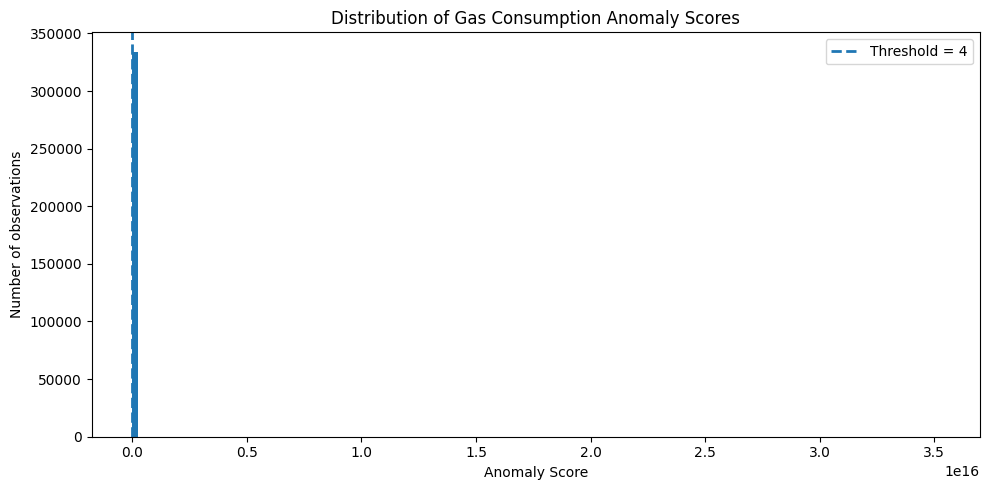

In [ ]:
# ============================================================
# STEP 2C — ANOMALY SCORE DISTRIBUTION
# ============================================================

scores = long_df["Anomaly Score"].dropna()

plt.figure(figsize=(10, 5))

plt.hist(
    scores,
    bins=150
)

plt.axvline(
    ANOMALY_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {ANOMALY_THRESHOLD}"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of observations")
plt.title("Distribution of Gas Consumption Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 2D — VISUALIZE ONE METER
# ============================================================

# Find a meter with enough valid consumption observations
meter_counts = (
    long_df
    .groupby(["Consumer ID", "Meter ID"])["Consumption"]
    .count()
    .sort_values(ascending=False)
)

# Select the first meter with sufficient data
selected_consumer = meter_counts.index[1][0]
selected_meter = meter_counts.index[1][1]

meter_data = long_df[
    (long_df["Consumer ID"] == selected_consumer) &
    (long_df["Meter ID"] == selected_meter)
].copy()

print("Selected Consumer ID:", selected_consumer)
print("Selected Meter ID:", selected_meter)

Selected Consumer ID: 017700302300010
Selected Meter ID: ELS3032545182922


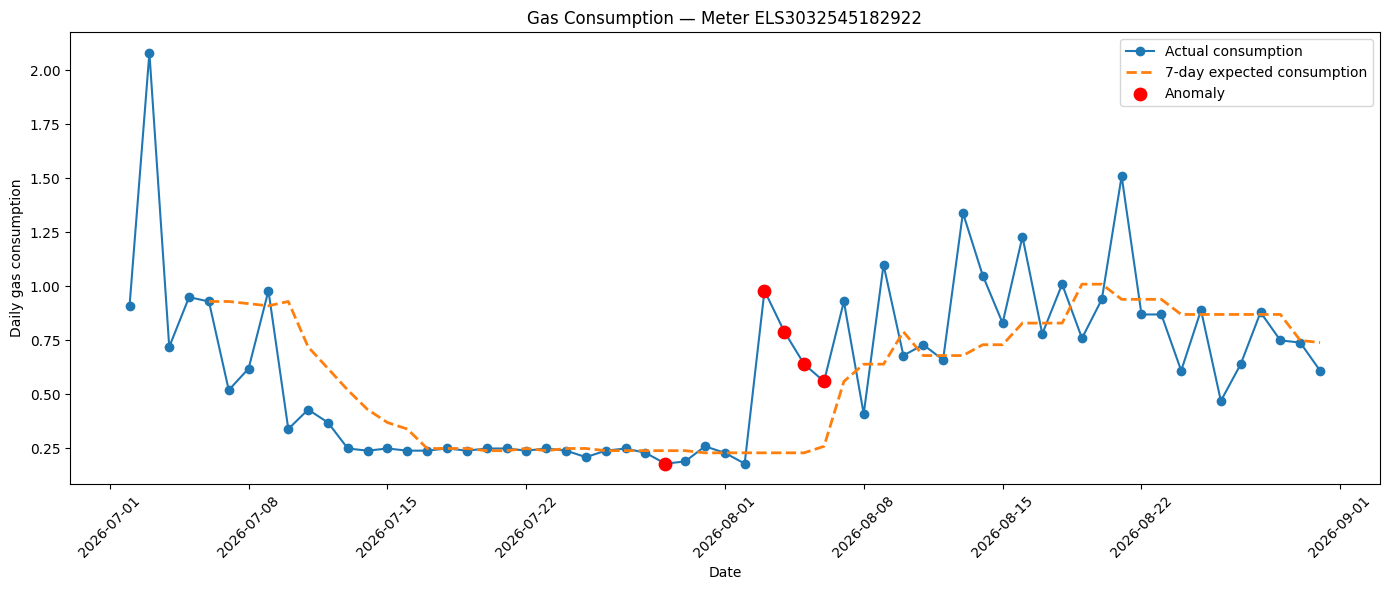

In [ ]:
# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    meter_data["Date"],
    meter_data["Consumption"],
    marker="o",
    label="Actual consumption"
)

plt.plot(
    meter_data["Date"],
    meter_data["Rolling Median"],
    linestyle="--",
    linewidth=2,
    label="7-day expected consumption"
)

# Highlight anomalies in RED
anomalies = meter_data[meter_data["Anomaly"]]

plt.scatter(
    anomalies["Date"],
    anomalies["Consumption"],
    s=80,
    color="red",
    label="Anomaly",
    zorder=3
)

plt.xlabel("Date")
plt.ylabel("Daily gas consumption")
plt.title(
    f"Gas Consumption — Meter {selected_meter}"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 2G — ANOMALIES PER METER
# ============================================================

meter_anomaly_summary = (
    long_df
    .groupby(["Consumer ID", "Meter ID"])
    .agg(
        Total_Days=("Date", "count"),
        Valid_Days=("Anomaly Score", "count"),
        Anomalies=("Anomaly", "sum"),
        Avg_Consumption=("Consumption", "mean"),
        Max_Consumption=("Consumption", "max")
    )
    .reset_index()
)

meter_anomaly_summary["Anomaly Rate (%)"] = (
    meter_anomaly_summary["Anomalies"]
    / meter_anomaly_summary["Valid_Days"]
    * 100
)

meter_anomaly_summary = (
    meter_anomaly_summary
    .sort_values(
        "Anomalies",
        ascending=False
    )
)

display(
    meter_anomaly_summary.head(20)
)

,Consumer ID,Meter ID,Total_Days,Valid_Days,Anomalies,Avg_Consumption,Max_Consumption,Anomaly Rate (%)
1793,100456909040077,FIOR034426015583,62,53,21,0.045410,0.22,39.622642
638,017701704400590,FIOR034426017278,62,53,20,0.289016,1.54,37.735849
5163,100464041300001,FIOR034426015176,62,52,20,0.017213,0.03,38.461538
6860,100474202604688,ELS3032545180312,62,53,18,0.118689,1.15,33.962264
4530,100464000500004,FIOR034426015474,62,49,18,0.139508,0.63,36.734694
1550,100454000107080,ELS3032545184521,62,48,17,0.493770,4.28,35.416667
5218,100464045600085,ELS3032545182014,62,52,17,0.462951,2.02,32.692308
6801,100474202600629,ELS3032545181439,62,53,16,0.111803,1.05,30.188679
6607,100474200300043,FIOR034426016400,62,52,16,0.374590,0.46,30.769231
6806,100474202600744,ELS3032545180533,62,53,15,0.307049,0.97,28.301887
